In [ ]:
pip install scikit-learn

In [ ]:
!pip install -q gensim

In [ ]:
import numpy as np
import pandas as pd
import gensim.downloader as api
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv("train_preprocessed.csv")
test_df = pd.read_csv("test_preprocessed.csv")

In [ ]:
train_texts = train_df['cleaned'].fillna('').astype(str).tolist()
test_texts = test_df['cleaned'].fillna('').astype(str).tolist()

In [ ]:
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(train_texts)

In [ ]:
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

In [ ]:
max_len = max(max(len(x) for x in train_sequences), max(len(x) for x in test_sequences))
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')

In [ ]:
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y_train = train_df['Sentiment'].map(label_map).values
y_test = test_df['Sentiment'].map(label_map).values

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print(f"Tokenizationed — Vocab size: {vocab_size}, Max len: {max_len}")

Tokenizationed — Vocab size: 150195, Max len: 80


In [ ]:
fasttext_model = api.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [ ]:
embedding_dim = 300

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in fasttext_model:
        embedding_matrix[i] = fasttext_model[word]

In [ ]:
embedding_dim_fast = 100
embedding_matrix_fast = np.zeros((vocab_size, embedding_dim_fast))
for word, i in tokenizer.word_index.items():
    if word in fasttext_model:
        embedding_matrix_fast[i] = fasttext_model[word][:embedding_dim_fast]

In [ ]:
class RelativePositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.max_len = max_len
        self.rel_pos_embeddings = self.add_weight(
            name="rel_pos",
            shape=(2 * max_len - 1, embed_dim),
            initializer='random_normal',
            trainable=True
        )

    def call(self, x):
        seq_len = tf.shape(x)[1]
        diag_indices = tf.range(seq_len) - tf.range(seq_len) + self.max_len - 1
        diag_embeddings = tf.gather(self.rel_pos_embeddings, diag_indices)
        return tf.expand_dims(diag_embeddings, 0)


In [ ]:
class CausalTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads=2):
        super().__init__()
        self.attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.norm = tf.keras.layers.LayerNormalization()
        self.add = tf.keras.layers.Add()

    def call(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        mask = tf.tile(tf.expand_dims(mask, 0), [batch_size, 1, 1])
        attn_output = self.attn(x, x, attention_mask=mask)
        return self.norm(self.add([x, attn_output]))


In [ ]:
from sklearn.utils import class_weight

In [ ]:
def build_fast_model(vocab_size, embedding_dim, max_len):
    inputs = tf.keras.Input(shape=(max_len,))

    word_emb = tf.keras.layers.Embedding(input_dim=vocab_size,
                                         output_dim=embedding_dim,
                                         weights=[embedding_matrix_fast],
                                         trainable=False)(inputs)

    rel_pos = RelativePositionEmbedding(max_len, embedding_dim)(word_emb)
    x = word_emb + rel_pos

    x = CausalTransformerBlock(embed_dim=embedding_dim)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)
model = build_fast_model(vocab_size, embedding_dim_fast, max_len)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

Class Weights: {0: 1.9637254170706844, 1: 1.9534170515602876, 2: 0.5053464687713439}
Epoch 1/5
7899/7899 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - accuracy: 0.6163 - loss: 0.8598 - val_accuracy: 0.7603 - val_loss: 0.6066
Epoch 2/5
7899/7899 ━━━━━━━━━━━━━━━━━━━━ 69s 4ms/step - accuracy: 0.7492 - loss: 0.6799 - val_accuracy: 0.7961 - val_loss: 0.5337
Epoch 3/5
7899/7899 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.7645 - loss: 0.6529 - val_accuracy: 0.7918 - val_loss: 0.5775
Epoch 4/5
7899/7899 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.7691 - loss: 0.6397 - val_accuracy: 0.7855 - val_loss: 0.5618


In [ ]:
model = build_fast_model(vocab_size, embedding_dim_fast, max_len)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 80, 100)   │ 15,019,500 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relative_position_… │ (1, 80, 100)      │     15,900 │ embedding_1[0][0] │
│ (RelativePositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 80, 100)   │          0 │ embedding_1[0][0… │
│                     │                   │            │ relative_positio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_transformer… │ (None, 80, 100)   │     80,900 │ add_2[0][0]       │
│ (CausalTransformer… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ causal_transform… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      6,464 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        195 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,122,959 (57.69 MB)

 Trainable params: 103,459 (404.14 KB)

 Non-trainable params: 15,019,500 (57.29 MB)

In [ ]:
y_pred = model.predict(X_test).argmax(axis=1)


4232/4232 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.02      0.01      0.01     22984
     Neutral       0.15      0.80      0.25     23105
    Positive       0.00      0.00      0.00     89311

    accuracy                           0.14    135400
   macro avg       0.05      0.27      0.09    135400
weighted avg       0.03      0.14      0.04    135400



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
report_dict = classification_report(y_test, y_pred, target_names=label_map.keys(), output_dict=True)
f1_pos = report_dict['Positive']['f1-score']
f1_neg = report_dict['Negative']['f1-score']
f1_neu = report_dict['Neutral']['f1-score']
print(f"F1 Score (Positive) = {f1_pos:.4f}")
print(f"F1 Score (Negative) = {f1_neg:.4f}")
print(f"F1 Score (Neutral)  = {f1_neu:.4f}")

F1 Score (Positive) = 0.0000
F1 Score (Negative) = 0.0098
F1 Score (Neutral)  = 0.2457


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


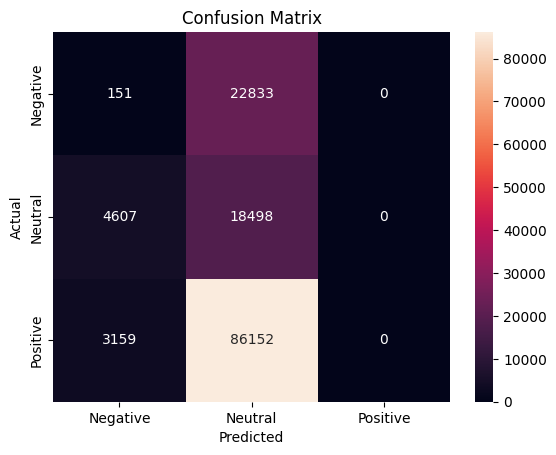

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
probs = model.predict(X_test)
auc = roc_auc_score(tf.keras.utils.to_categorical(y_test, 3), probs, multi_class='ovr')
print(f"AUC Score: {auc:.4f}")

4232/4232 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
AUC Score: 0.3972


Tuning

In [ ]:
!pip install -q keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 8.4 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from tensorflow.keras import layers, models, optimizers

def build_model(hp):
    embed_dim = hp.Choice('embed_dim', [64, 128, 256])
    num_heads = hp.Choice('num_heads', [2, 4])
    num_blocks = hp.Int('num_blocks', 1, 3)
    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    dropout_rate = hp.Choice('dropout_rate', [0.2, 0.3, 0.5])

    inputs = tf.keras.Input(shape=(X_train.shape[1],))

    # Embedding Layer using your embedding matrix
    emb = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inputs)

    # Add relative position embeddings
    pos_emb = RelativePositionEmbedding(max_len=X_train.shape[1], embed_dim=embedding_dim)(emb)
    x = emb + pos_emb

    # Stacking transformer blocks
    for _ in range(num_blocks):
        x = CausalTransformerBlock(embed_dim=embed_dim, num_heads=num_heads)(x)
        x = layers.LayerNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=8,
    executions_per_trial=1,
    directory='kt_dir',
    project_name='causal_transformer_tuning'
)

In [ ]:
tuner.search(X_train, y_train,
             epochs=3,
             validation_data=(X_test, y_test),
             batch_size=32)


Trial 8 Complete [00h 04m 35s]
val_accuracy: 0.6596085429191589

Best val_accuracy So Far: 0.8460339903831482
Total elapsed time: 00h 59m 48s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
print(best_hp.values)

# Evaluate best model
best_model.evaluate(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters:
{'embed_dim': 64, 'num_heads': 2, 'num_blocks': 2, 'learning_rate': 0.0001, 'dropout_rate': 0.3}
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8469 - loss: 0.4082


[0.4115878939628601, 0.8460339903831482]

After running this cell, please restart the runtime again by going to "Runtime" -> "Restart runtime" in the Colab menu. Then, try running the import cell again.